# Seaborn 

In [1]:
# Def: Seaborn is a High level visualization library built on the top of Matplotlib.
# Seaborn is famous for statistical visualization.
# Seaborn support complex charts like Pair plot, KDE plot.
# Seaborn has inbuilt datasets.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
df = sns.load_dataset('flights')
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


# Line chart

In [6]:
# Query: Show the total passanger fly yearwise

timeline = df.groupby("year")["passengers"].sum().reset_index()
print(timeline)

    year  passengers
0   1949        1520
1   1950        1676
2   1951        2042
3   1952        2364
4   1953        2700
5   1954        2867
6   1955        3408
7   1956        3939
8   1957        4421
9   1958        4572
10  1959        5140
11  1960        5714


<Axes: xlabel='year', ylabel='passengers'>

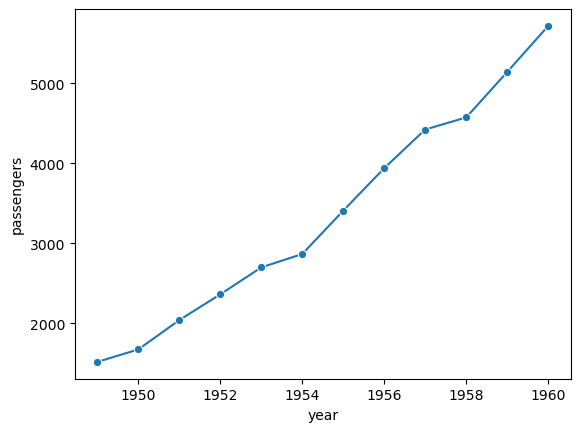

In [7]:
sns.lineplot(x = "year", y = "passengers", data = timeline, marker = 'o')

In [8]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

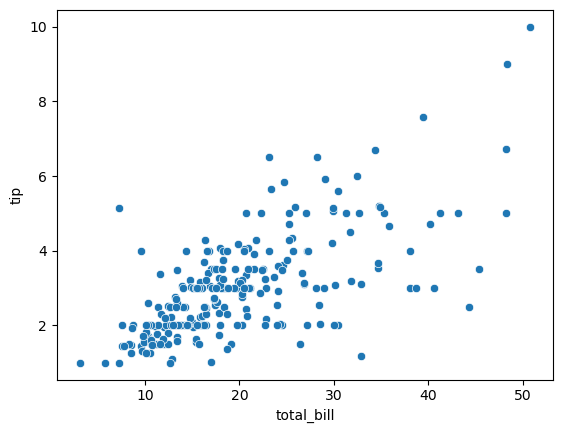

In [9]:
# Scatter plot

sns.scatterplot(x = "total_bill", y = "tip", data = df)

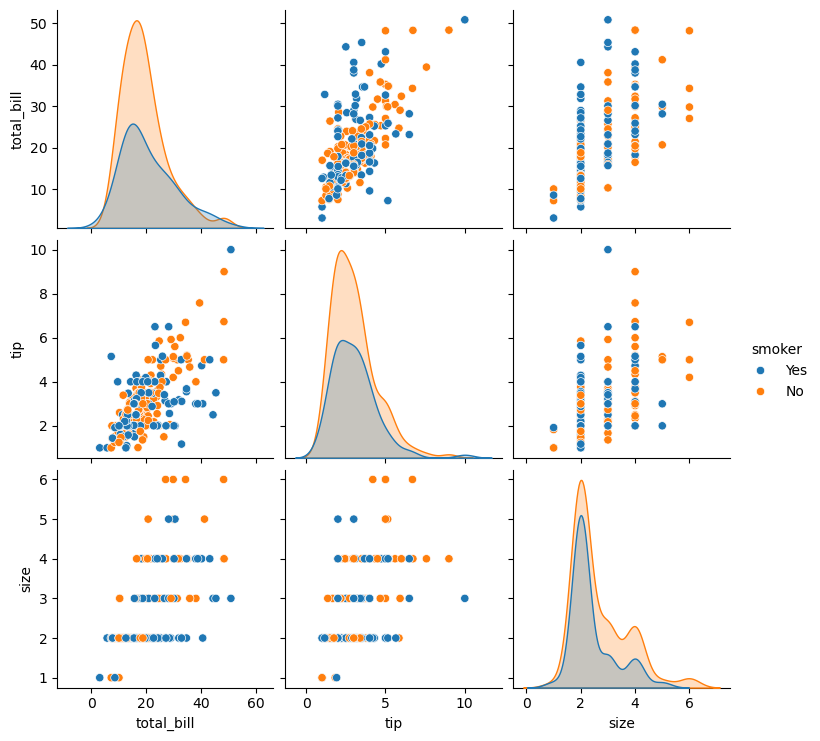

In [10]:
# pair plot

# pair plot will plot scatter plot for every pair of numerical columns.

sns.pairplot(df, hue='smoker')

# Heatmap

In [11]:
# Def: A heatmap helps to visualize correlations between different columns in nicer way.

corr = df.corr(numeric_only = True)

print(corr)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


<Axes: >

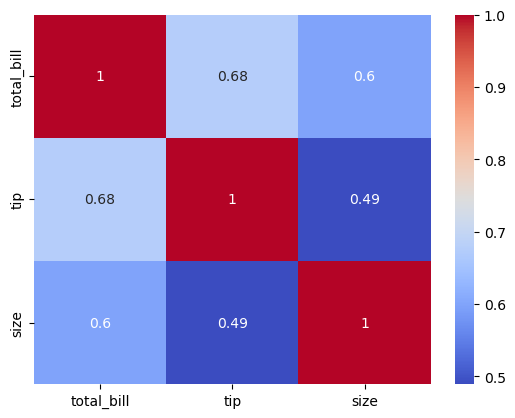

In [12]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")

# Categorical columns : pivot table + heatmap

In [13]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


sex   Male  Female
day               
Thur    30      32
Fri     10       9
Sat     59      28
Sun     58      18


<Axes: xlabel='sex', ylabel='day'>

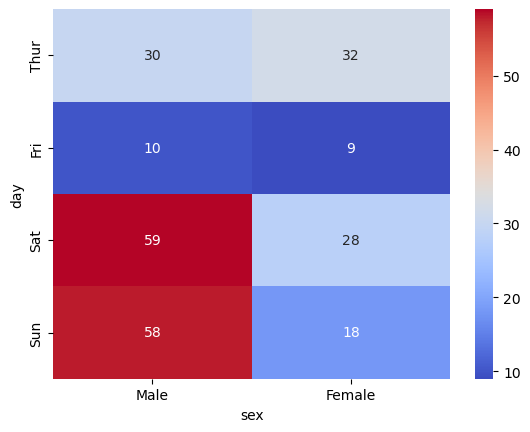

In [14]:
# aggfunc : counts number of rows for each combination
# fill_value : replace the null value with 0
pivot = df.pivot_table(index = "day", columns = "sex", aggfunc = "size", fill_value = 0, observed=False)
print(pivot)

sns.heatmap(pivot, annot = True, cmap = "coolwarm")

sex        Male     Female
day                       
Thur  18.714667  16.715312
Fri   19.857000  14.145556
Sat   20.802542  19.680357
Sun   21.887241  19.872222


<Axes: xlabel='sex', ylabel='day'>

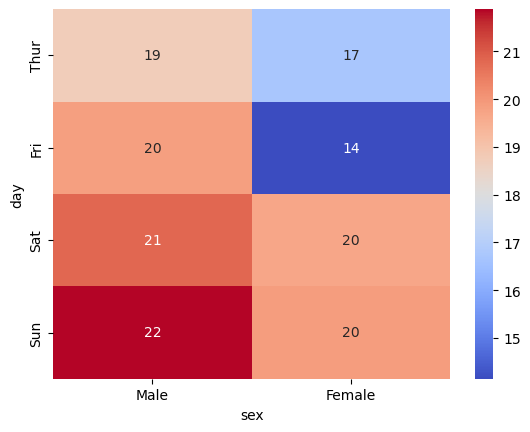

In [15]:
pivot = df.pivot_table(index = "day", columns = "sex", values ="total_bill",  aggfunc = "mean", fill_value = 0, observed=False)
print(pivot)

sns.heatmap(pivot, annot = True, cmap = "coolwarm")